# Size, volatility and degree: the two-slope size--variance relation

Full-scale study (exponential graph, $C=5$, $\mu=\mu_c$) of how a firm's **size** $\bar S_i$ and
**growth volatility** $\sigma_i$ depend on its network **degree** $k_i$, and how the two combine to
produce the size--variance relation $\sigma(\bar S)$.

The relation is **not a single power law**. It is a *V* in log--log:
$$\sigma(\bar S)\;=\;\underbrace{\text{field/diversification},\ \sigma\!\sim\!\bar S^{-\beta_{\downarrow}}}_{\text{small }\bar S}\ \ \oplus\ \ \underbrace{\text{self-limitation},\ \sigma\!\sim\!\bar S^{+\beta_{\uparrow}}}_{\text{large }\bar S}.$$
Both branches factor through the degree, since size and volatility are each functions of $k$:
$$\text{slope of }\sigma(\bar S)\;=\;\frac{\text{slope of }\sigma(k)}{\text{slope of }\bar S(k)}.$$
This notebook fits both slopes at full scale and checks that composition.

In [1]:
import multiprocessing as mp
mp.set_start_method("fork", force=True)   # spawn re-imports the kernel and breaks the pool

import numpy as np
import networkx as nx
import scipy.sparse as sp
import matplotlib.pyplot as plt

import glv
glv.apply_style()

N = 1000            # species / firms
sigma = 0.2         # interaction disorder
C = 5               # mean degree (single connectivity for this study)
n_runs = 40         # graph realizations
tau_max = 1e6       # rescaled-time horizon
n_years = 100       # sampled "years" of physical time
n_workers = min(8, (mp.cpu_count() or 2))
rng = np.random.default_rng(20)

## Degree sequence (inline) and graph builders

Exponential degree law, $k\sim\mathrm{Exp}(C)$. The realized degree $k_i$ is read back from the built
matrix (the configuration model collapses multi-edges and drops self-loops, so the realized degree
differs from the drawn one).

In [2]:
def exponential_degrees(C, rng):
    return np.maximum(rng.exponential(C, N).astype(int), 1)

def make_even(deg):
    deg = np.asarray(deg).copy()
    if deg.sum() % 2:
        deg[0] += 1
    return deg

def binary_adjacency(deg, seed):
    seq = [int(s) for s in make_even(deg)]
    G = nx.Graph(nx.configuration_model(seq, seed=seed))
    G.remove_edges_from(nx.selfloop_edges(G))
    return sp.csr_array(nx.to_scipy_sparse_array(G, format="csr", dtype=float))

def realized_degree(W):
    # nonzeros per row of the (zero-diagonal) interaction matrix = realized degree
    return np.asarray((W != 0).sum(axis=1)).ravel().astype(int)

## Locate $\mu_c$

Shape-scalar zero-crossing, averaged over a few graphs, on a $\mu$-grid centred on $1/\langle g^2\rangle$
with $g=k/C$.

In [3]:
def estimate_mu_c(C, n_graphs=4):
    vals = []
    for s in range(n_graphs):
        A = binary_adjacency(exponential_degrees(C, rng), seed=100 + s)
        g2 = np.mean((np.asarray(A.sum(1)).ravel() / C) ** 2)
        center = 1.0 / max(g2, 1e-6)
        mus = np.linspace(max(0.0, center - 0.3 * center), center + 0.6 * center + 0.1, 16)
        res = glv.find_mu_c_shape_scalar(A, C=C, sigma=sigma, mus=mus, tau_max=1e4, seed=200 + s)
        if np.isfinite(res["mu_c"]):
            vals.append(res["mu_c"])
    return float(np.mean(vals)) if vals else np.nan

mu_c = estimate_mu_c(C)
print(f"mu_c = {mu_c:.4f}")

mu_c = 0.4856


## Full-scale sweep: per-firm $(\bar S_i,\sigma_i,k_i)$

Draw `n_runs` graphs at $\mu_c$, integrate the rescaled dynamics, and pool the per-firm time-averaged
size $\bar S_i$, MAD volatility $\sigma_i=\sqrt{\pi/2}\,\mathrm{MAD}(g_i)$ and realized degree $k_i$.
Degrees are read from each matrix and stay index-aligned with the per-species observables.

In [4]:
def run_sweep(mu, seed0=1000):
    Ws, degs, states = [], [], []
    r = np.random.default_rng(seed0)
    for _ in range(n_runs):
        deg = make_even(exponential_degrees(C, r))
        W = glv.generate_matrix(deg, C, mu=mu, sigma=sigma)
        Ws.append(W)
        degs.append(realized_degree(W))
        x0 = r.uniform(0.1, 1.0, N)
        M0 = x0.sum()
        states.append(np.concatenate([x0 / M0, [M0], [0.0]]))
    res = glv.sweep_observables(
        Ws=Ws, initial_states=states, N=N, tau_max=tau_max, n_years=n_years,
        method="RK45", max_step=1e2, n_workers=n_workers, normalization="cross_section",
    )
    Sbar, sig, deg = [], [], []
    n_ok = 0
    for k_run, r_run in zip(degs, res):
        if r_run is None:
            continue
        n_ok += 1
        Sbar.append(r_run["avg_size"])
        sig.append(r_run["volatility"])
        deg.append(k_run)
    return (np.concatenate(Sbar), np.concatenate(sig), np.concatenate(deg), n_ok)

Sbar, sigma_i, degree, n_ok = run_sweep(mu_c)
m = np.isfinite(Sbar) & np.isfinite(sigma_i) & (Sbar > 0) & (sigma_i > 0) & (degree >= 1)
Sbar, sigma_i, degree = Sbar[m], sigma_i[m], degree[m]
np.savez("volatility_degree_results.npz", Sbar=Sbar, sigma=sigma_i, degree=degree, mu_c=mu_c)
print(f"runs ok: {n_ok}/{n_runs}   firms pooled: {Sbar.size}   degree range: [{degree.min()}, {degree.max()}]")

runs ok: 40/40   firms pooled: 39998   degree range: [1, 52]


## Fitting helpers

In [5]:
def equal_count_bins(x, y, n_bins=25):
    o = np.argsort(x); x, y = x[o], y[o]
    parts = np.array_split(np.arange(x.size), n_bins)
    bx = np.array([x[i].mean() for i in parts])
    by = np.array([y[i].mean() for i in parts])
    return bx, by

def loglog_slope(x, y):
    return np.polyfit(np.log10(x), np.log10(y), 1)[0]

def piecewise(bx, by, split=None):
    j = int(np.argmin(by)) if split is None else split
    s_lo = loglog_slope(bx[:j + 1], by[:j + 1])
    s_hi = loglog_slope(bx[j:], by[j:])
    return j, s_lo, s_hi

def degree_means(degree, value, min_count=25):
    ks, mean_v, mean_s, counts = [], [], [], []
    for k in np.unique(degree):
        sel = degree == k
        if sel.sum() >= min_count:
            ks.append(k); counts.append(int(sel.sum()))
            mean_v.append(value[sel].mean()); mean_s.append(Sbar[sel].mean())
    return np.array(ks), np.array(mean_v), np.array(mean_s), np.array(counts)

## $\sigma(k)$ and $\bar S(k)$: the underlying U and the size--degree map

In [6]:
kk, sig_k, S_k, cnt = degree_means(degree, sigma_i)
jk, sk_lo, sk_hi = piecewise(kk, sig_k)
k_split = kk[jk]
a_lo = loglog_slope(kk[kk <= k_split], S_k[kk <= k_split])
a_hi = loglog_slope(kk[kk >= k_split], S_k[kk >= k_split])

print(f"sigma(k): U-minimum at k = {k_split}")
print(f"   descending (low k):  sigma ~ k^{sk_lo:+.3f}   (diversification, ideal -1/2)")
print(f"   ascending  (high k): sigma ~ k^{sk_hi:+.3f}   (self-limitation)")
print(f"size(k):   low-k  S ~ k^{a_lo:+.3f}     high-k  S ~ k^{a_hi:+.3f}")

sigma(k): U-minimum at k = 10
   descending (low k):  sigma ~ k^-0.401   (diversification, ideal -1/2)
   ascending  (high k): sigma ~ k^+0.660   (self-limitation)
size(k):   low-k  S ~ k^+0.728     high-k  S ~ k^+1.157


## $\sigma(\bar S)$: the V and the two slopes

In [7]:
bs, bv = equal_count_bins(Sbar, sigma_i, n_bins=25)
jS, beta_down, beta_up = piecewise(bs, bv)
S_split = bs[jS]
print(f"sigma(Sbar): V-minimum at Sbar = {S_split:.3f}  (bin {jS}/{len(bs)})")
print(f"   descending slope  beta_down = {beta_down:+.3f}   (field / diversification)")
print(f"   ascending  slope  beta_up   = {beta_up:+.3f}   (self-limitation, the upturn)")

print("\\ncomposition check  slope_sigma(S) = slope_sigma(k) / slope_S(k):")
print(f"   descending: {sk_lo:+.3f} / {a_lo:.3f} = {sk_lo / a_lo:+.3f}   (measured {beta_down:+.3f})")
print(f"   ascending:  {sk_hi:+.3f} / {a_hi:.3f} = {sk_hi / a_hi:+.3f}   (measured {beta_up:+.3f})")

sigma(Sbar): V-minimum at Sbar = 0.949  (bin 16/25)
   descending slope  beta_down = -1.005   (field / diversification)
   ascending  slope  beta_up   = +0.762   (self-limitation, the upturn)
\ncomposition check  slope_sigma(S) = slope_sigma(k) / slope_S(k):
   descending: -0.401 / 0.728 = -0.551   (measured -1.005)
   ascending:  +0.660 / 1.157 = +0.570   (measured +0.762)


## The upturn is intrinsic to high degree (within-degree $\sigma(\bar S)$ tails)

In [8]:
print("tail slope of sigma vs Sbar WITHIN a fixed-degree group:")
for k0 in [2, 4, 6, 8, 10, 12]:
    sel = np.abs(degree - k0) <= 1
    if sel.sum() < 60:
        continue
    sb, sg = equal_count_bins(Sbar[sel], sigma_i[sel], n_bins=8)
    h = int(len(sb) * 0.5)
    tail = loglog_slope(sb[h:], sg[h:])
    print(f"   k ~ {k0:2d} (n={sel.sum():5d}):  tail slope = {tail:+.3f}")

tail slope of sigma vs Sbar WITHIN a fixed-degree group:
   k ~  2 (n=22127):  tail slope = -0.830
   k ~  4 (n=10012):  tail slope = +0.443
   k ~  6 (n= 6641):  tail slope = +0.850
   k ~  8 (n= 4477):  tail slope = +1.033
   k ~ 10 (n= 2976):  tail slope = +0.925
   k ~ 12 (n= 1987):  tail slope = +1.005


## Figures

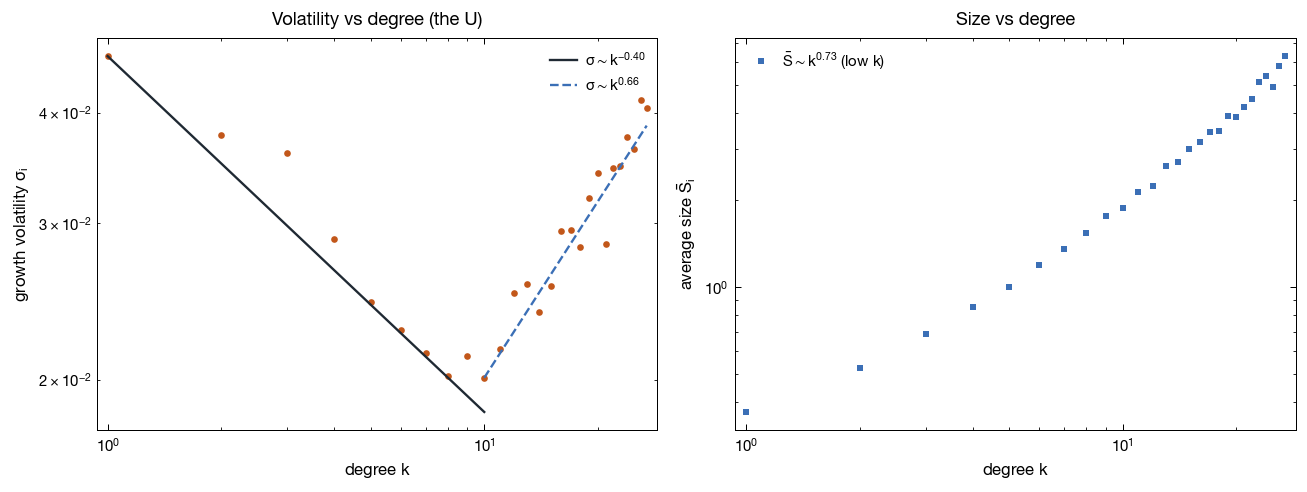

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].loglog(kk, sig_k, "o", color="#c2571a")
xf = np.logspace(np.log10(kk.min()), np.log10(k_split), 50)
ax[0].loglog(xf, sig_k[0] * (xf / kk[0]) ** sk_lo, "-", color="#1f2933",
             label=rf"$\sigma\sim k^{{{sk_lo:.2f}}}$")
xf2 = np.logspace(np.log10(k_split), np.log10(kk.max()), 50)
ax[0].loglog(xf2, sig_k[jk] * (xf2 / k_split) ** sk_hi, "--", color="#3b6fb6",
             label=rf"$\sigma\sim k^{{{sk_hi:.2f}}}$")
ax[0].set_xlabel(r"degree $k$"); ax[0].set_ylabel(r"growth volatility $\sigma_i$")
ax[0].set_title(r"Volatility vs degree (the U)"); ax[0].legend()

ax[1].loglog(kk, S_k, "s", color="#3b6fb6", label=rf"$\bar S\sim k^{{{a_lo:.2f}}}$ (low $k$)")
ax[1].set_xlabel(r"degree $k$"); ax[1].set_ylabel(r"average size $\bar S_i$")
ax[1].set_title(r"Size vs degree"); ax[1].legend()
plt.tight_layout(); plt.show()

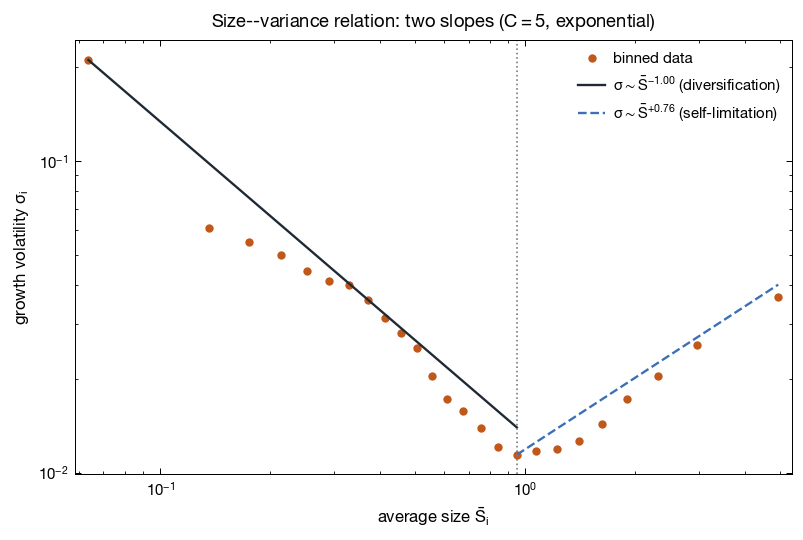

In [10]:
fig, ax = plt.subplots(figsize=(6.8, 4.6))
ax.loglog(bs, bv, "o", ms=5, color="#c2571a", label="binned data")
xd = np.logspace(np.log10(bs.min()), np.log10(S_split), 50)
ax.loglog(xd, bv[0] * (xd / bs[0]) ** beta_down, "-", color="#1f2933",
          label=rf"$\sigma\sim \bar S^{{{beta_down:.2f}}}$ (diversification)")
xu = np.logspace(np.log10(S_split), np.log10(bs.max()), 50)
ax.loglog(xu, bv[jS] * (xu / S_split) ** beta_up, "--", color="#3b6fb6",
          label=rf"$\sigma\sim \bar S^{{+{beta_up:.2f}}}$ (self-limitation)")
ax.axvline(S_split, color="#7a7d83", ls=":", lw=1)
ax.set_xlabel(r"average size $\bar S_i$"); ax.set_ylabel(r"growth volatility $\sigma_i$")
ax.set_title(r"Size--variance relation: two slopes ($C=5$, exponential)")
ax.legend()
plt.tight_layout(); plt.show()

## Summary

- **Size grows with degree**, $\bar S\sim k^{a}$: more cooperative neighbours, larger abundance.
- **Volatility is U-shaped in degree**: a falling $\sim k^{-1/2}$ diversification branch (the field is
  averaged over $k$ neighbours) and a rising self-limitation branch (the $-S/N$ carrying-capacity term
  injects size-proportional fluctuations that diversification cannot suppress).
- Re-plotted against size, the U becomes the **V** of $\sigma(\bar S)$: the descending branch is the
  MSB-compatible $\sigma\sim\bar S^{-\beta_\downarrow}$, the ascending branch is the upturn
  $\sigma\sim\bar S^{+\beta_\uparrow}$, and both compose through $\bar S(k)$.
- A single $\beta$ is a straight line averaged over both branches; the faithful description is two slopes
  meeting at a minimum near the mean size.